# Preprocessing

In questo notebook verranno eseguite le attivita' di preprocessing del dataset.
Ogni split preprocessato viene salvato nella cartella apposita `data/processed`.

## Download dataset

Scarichiamo il dataset con il codice fornito direttamente da *kaggle*.
Il dataset è composto da 7 cartelle che rappresentano le classi.
* angry
* disgust
* fear
* happy
* neutral
* sad 
* surprise

In [5]:
from time import perf_counter
import kagglehub, os

# Imposta la cartella del progetto
PROJECT_ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")

start_time = perf_counter()
print("[Download dataset] Avvio download/caricamento dataset da Kaggle...", flush=True)

# Download diretta da kaggle. Se il dataset e' gia' in cache, KaggleHub restituisce subito il path.
path = kagglehub.dataset_download("msambare/fer2013")

elapsed = perf_counter() - start_time
print(f"[Download dataset] Completato in {elapsed:.1f}s", flush=True)
print("Path to dataset files:", path)


[Download dataset] Avvio download/caricamento dataset da Kaggle...
[Download dataset] Completato in 0.8s
Path to dataset files: C:\Users\ledoa\.cache\kagglehub\datasets\msambare\fer2013\versions\1


### Analisi del Bilanciamento delle Classi (Class Imbalance)
Si può subito stabilire come il training set sia fortemente sbilanciato con un'ampia predominanza di campioni di classe `happy` (25.13%), una presenza irrisoria di quelli di classe `disgust` (1.52%) e una presenza moderata delle altre cinque classi (`neutral`, `sad`, `fear`, `angry`, `surprise`) tra l'11% e il 17%.

Anche nel caso del test set si può notare un forte sbilanciamento in cui i campioni di classe `happy` (24.71%) continuano a predominare, quelli di classe `disgust` (1.55%) rimangono scarsi mentre le altre cinque classi (`neutral`, `sad`, `fear`, `angry`, `surprise`) sono ancora quantitativamente moderate, occupando ognuna tra l'11% e il 17% dell'intero dataset.

In [6]:
import matplotlib.pyplot as plt, seaborn as sns

def show_distr_classes(base, child_dir, ax=None):
    # Seleziona la cartella base
    if base in ["Original", "Processed"]:
        base_dir = os.path.join(DATA_DIR, base)
    else:
        raise ValueError("'base' deve essere 'Original' o 'Processed'")

    # Seleziona lo split
    if child_dir in ["Train", "Test", "Validation"]:
        dir_path = os.path.join(base_dir, child_dir)
    else:
        raise ValueError("'child_dir' deve essere 'Train', 'Test' o 'Validation'")

    if not os.path.exists(dir_path):
        raise FileNotFoundError(f"La cartella '{dir_path}' non esiste.")

    class_names = sorted(os.listdir(dir_path))

    class_counts = {
        emotion: len(os.listdir(os.path.join(dir_path, emotion)))
        for emotion in class_names
    }

    class_counts = dict(
        sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
    )

    # Se non viene passato un asse, crea una nuova figura
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
        created_fig = True

    sns.barplot(
        x=list(class_counts.keys()),
        y=list(class_counts.values()),
        ax=ax
    )

    ax.set_title(f"Distribuzione delle classi nel {child_dir} Set ({base})")
    ax.set_xlabel("Classe (Emozione)")
    ax.set_ylabel("Numero di campioni (immagini)")
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

    # Se è un grafico singolo lo mostro
    if created_fig:
        plt.tight_layout()
        plt.show()

        tot = sum(class_counts.values())
        print(f"Immagini totali su {child_dir}: {tot}")

        for emotion, count in class_counts.items():
            print(f"- {emotion}: {count} campioni ({count/tot*100:.2f}%)")

    return class_counts

def display_side_distr_classes(base1, split1, base2, split2):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    counts1 = show_distr_classes(base1, split1, ax=axes[0])
    counts2 = show_distr_classes(base2, split2, ax=axes[1])

    plt.tight_layout()
    plt.show()

    print(f"\n--- {split1} ({base1}) ---")
    tot1 = sum(counts1.values())
    print(f"Immagini totali: {tot1}")
    for emotion, count in counts1.items():
        print(f"- {emotion}: {count} campioni ({count/tot1*100:.2f}%)")

    print(f"\n--- {split2} ({base2}) ---")
    tot2 = sum(counts2.values())
    print(f"Immagini totali: {tot2}")
    for emotion, count in counts2.items():
        print(f"- {emotion}: {count} campioni ({count/tot2*100:.2f}%)")

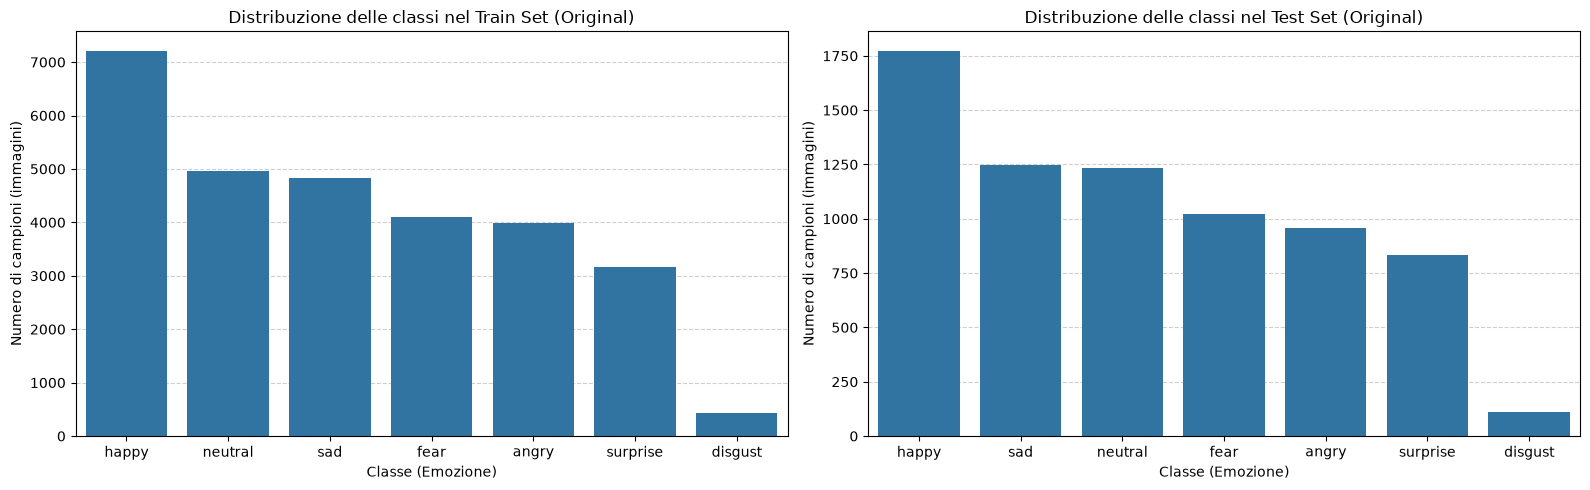


--- Train (Original) ---
Immagini totali: 28709
- happy: 7215 campioni (25.13%)
- neutral: 4965 campioni (17.29%)
- sad: 4830 campioni (16.82%)
- fear: 4097 campioni (14.27%)
- angry: 3995 campioni (13.92%)
- surprise: 3171 campioni (11.05%)
- disgust: 436 campioni (1.52%)

--- Test (Original) ---
Immagini totali: 7178
- happy: 1774 campioni (24.71%)
- sad: 1247 campioni (17.37%)
- neutral: 1233 campioni (17.18%)
- fear: 1024 campioni (14.27%)
- angry: 958 campioni (13.35%)
- surprise: 831 campioni (11.58%)
- disgust: 111 campioni (1.55%)


In [7]:
display_side_distr_classes("Original", "Train", "Original", "Test")

## Visualizzazione immagini

Visualizziamo 12 immagini assieme alle rispettive etichette per farci un'idea delle immagini che compongono il dataset.

[Visualizzazione] Cerco immagini di esempio...
[Visualizzazione] Immagini trovate: 35887


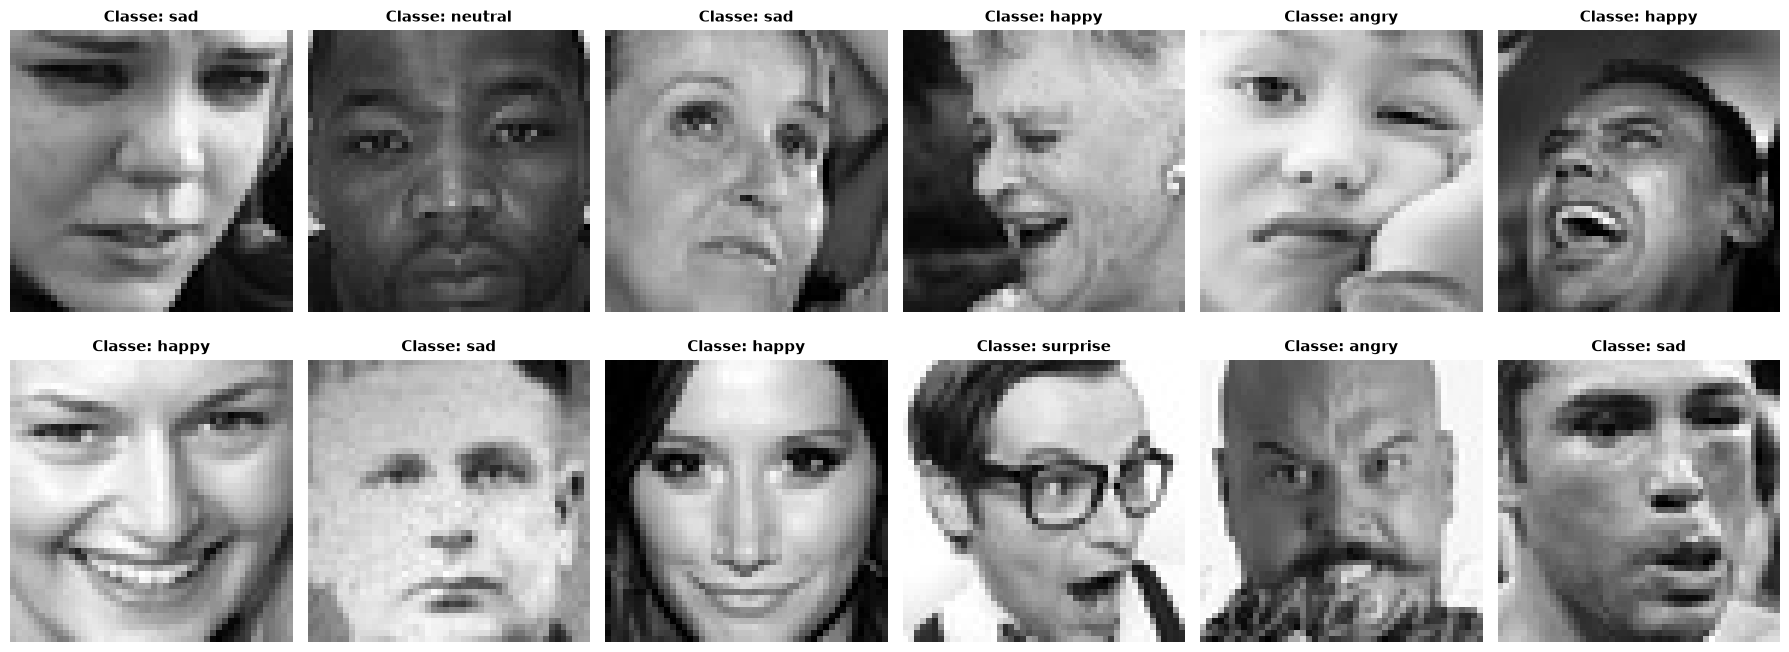

[Visualizzazione] Completata in 1.9s


In [8]:
from time import perf_counter
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

start_time = perf_counter()
print("[Visualizzazione] Cerco immagini di esempio...", flush=True)

dataset_path = Path(path)

valid_extensions = [".jpg"]
all_images = [
    p for p in dataset_path.rglob("*") if p.suffix.lower() in valid_extensions
]

print(f"[Visualizzazione] Immagini trovate: {len(all_images)}", flush=True)

if not all_images:
    print(
        f"Nessuna immagine presente nel percorso: {dataset_path}"
    )
else:
    num_samples = 12
    samples = random.sample(all_images, min(num_samples, len(all_images)))

    num_rows = 2
    num_cols = 6

    plt.figure(figsize=(18, 7))

    for idx, img_path in enumerate(samples):
        emotion_class = img_path.parent.name
        title = f"Classe: {emotion_class}"

        img = Image.open(img_path)

        plt.subplot(num_rows, num_cols, idx + 1)

        plt.imshow(img, cmap="gray" if img.mode == "L" else None)
        plt.title(title, fontsize=11, fontweight="bold")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

elapsed = perf_counter() - start_time
print(f"[Visualizzazione] Completata in {elapsed:.1f}s", flush=True)


[Visualizzazione] Cerco immagini di esempio per classe...
[Visualizzazione] Immagini totali trovate: 35887


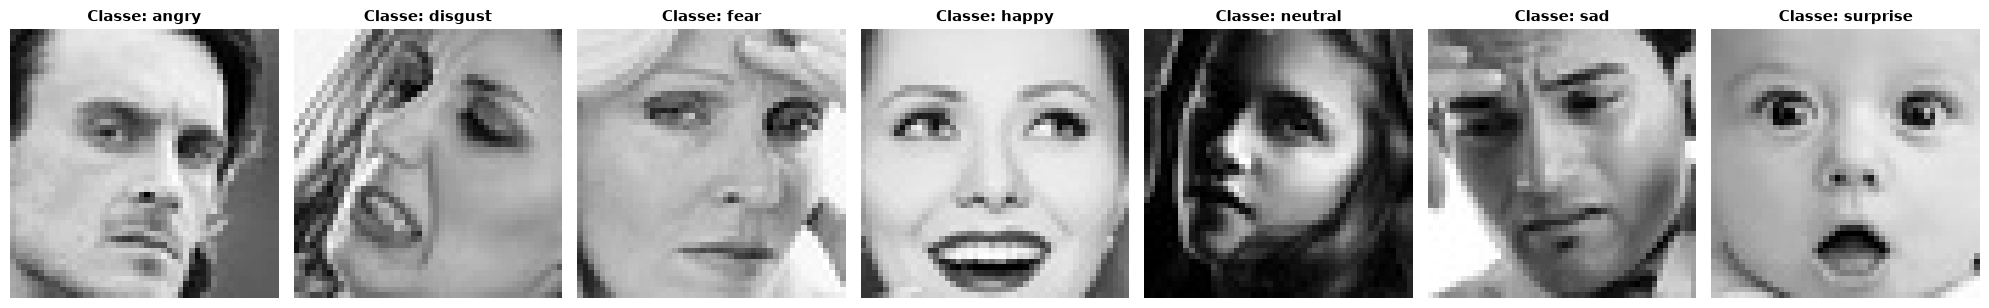

[Visualizzazione] Completata in 0.6s


In [9]:
from pathlib import Path
import random
from time import perf_counter
from PIL import Image
import matplotlib.pyplot as plt

start_time = perf_counter()
print("[Visualizzazione] Cerco immagini di esempio per classe...", flush=True)

dataset_path = Path(path)  # Assicuriamoci che 'path' sia definito precedentemente

valid_extensions = [".jpg"]
all_images = [
    p for p in dataset_path.rglob("*") if p.suffix.lower() in valid_extensions
]

print(f"[Visualizzazione] Immagini totali trovate: {len(all_images)}", flush=True)

if not all_images:
    print(f"Nessuna immagine presente nel percorso: {dataset_path}")
else:
    # --- RAGGRUPPAMENTO PER CLASSE ---
    # Creiamo un dizionario dove la chiave è la classe e il valore è la lista di immagini di quella classe
    images_by_class = {}
    for img_path in all_images:
        emotion_class = img_path.parent.name
        if emotion_class not in images_by_class:
            images_by_class[emotion_class] = []
        images_by_class[emotion_class].append(img_path)

    # Prendiamo una sola immagine casuale per ogni classe trovata
    samples = []
    # Ordiniamo le chiavi (classi) così l'output ha un ordine fisso/prevedibile
    for emotion_class in sorted(images_by_class.keys()):
        class_images = images_by_class[emotion_class]
        samples.append(random.choice(class_images))

    # --- CONFIGURAZIONE GRIGLIA (1 Riga x N Colonne) ---
    num_rows = 1
    num_cols = len(samples)  # Sarà 7 se sono presenti tutte le classi

    plt.figure(figsize=(20, 4))  # Dimensione ottimizzata per una riga lunga

    for idx, img_path in enumerate(samples):
        emotion_class = img_path.parent.name
        title = f"Classe: {emotion_class}"

        img = Image.open(img_path)

        plt.subplot(num_rows, num_cols, idx + 1)
        plt.imshow(img, cmap="gray" if img.mode == "L" else None)
        plt.title(title, fontsize=11, fontweight="bold")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

elapsed = perf_counter() - start_time
print(f"[Visualizzazione] Completata in {elapsed:.1f}s", flush=True)

## Preprocessing

Utilizziamo una funzione per applicare delle leggere modifice alle immagini per generare più campioni.
Le tecniche di preprocessing che andremo ad applicare sono:
* Flip orizzontale
* Traslazione
* Rotazione
* Zoom
* Normalizzazione 

#### Funzione per il preprocessing delle immagini

In [10]:
import torchvision.transforms as transforms

# Pipeline per preprocessing
def get_preprocessing_pipeline():
    preprocessing = transforms.Compose(
        [
            # 1. Flip Orizzontale casuale
            transforms.RandomHorizontalFlip(p=0.5),
            
            # 2. Rotazione casuale
            transforms.RandomRotation(degrees=15, fill=0),
            
            # 3. Traslazione e Zoom leggero
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), fill=0),
            
            # Conversione in tensore
            transforms.ToTensor(),
        ]
    )
    return preprocessing

### Preprocessing delle immagini
Preprocessiamo le immagini e le salviamo nella cartella *processed*, in modo da non toccare la cartella del dataset originale e avere più "versioni" del dataset.

In [11]:
# Utilizziamo funzioni di supporto per percorsi e monitoraggio.
# Cosi' si evitano problemi se il notebook viene lanciato dalla root o da notebooks.

import os
from pathlib import Path
from time import perf_counter
from datetime import datetime
from contextlib import contextmanager


def get_wd():
    current_dir = Path(os.getcwd())

    project_root = current_dir if (current_dir / "data").exists() else current_dir.parent

    final_path = project_root / "data"

    return Path(final_path)


def log_step(message):
    now = datetime.now().strftime("%H:%M:%S")
    print(f"[{now}] {message}", flush=True)


@contextmanager
def timed_step(name):
    start_time = perf_counter()
    log_step(f"INIZIO - {name}")
    try:
        yield
    finally:
        elapsed = perf_counter() - start_time
        log_step(f"FINE - {name} ({elapsed:.1f}s)")


def count_images_by_class(root_dir, extension=".jpg"):
    root_dir = Path(root_dir)
    counts = {}
    if not root_dir.exists():
        return counts

    for class_dir in sorted([p for p in root_dir.iterdir() if p.is_dir()]):
        counts[class_dir.name] = len(list(class_dir.glob(f"*{extension}")))

    return counts


In [12]:
import random
import shutil
from pathlib import Path
from PIL import Image
import torchvision.transforms as transforms
from tqdm.auto import tqdm

with timed_step("Preprocessing completo"):
    data_root = get_wd()

    dataset_originale_path = data_root / "original" / "train"
    processed_root = data_root / "processed"
    train_processed_path = processed_root / "train"
    validation_processed_path = processed_root / "validation"

    SEED = 42
    VALIDATION_SPLIT = 0.2
    AUGMENTATION_RATIO = 0.40

    random.seed(SEED)

    log_step(f"Dataset originale training: {dataset_originale_path}")
    log_step(f"Dataset preprocessato training: {train_processed_path}")
    log_step(f"Dataset preprocessato validation: {validation_processed_path}")
    log_step(f"Validation split: {VALIDATION_SPLIT:.0%}")
    log_step(f"Augmentation ratio sul training: {AUGMENTATION_RATIO:.0%}")

    pipeline = get_preprocessing_pipeline()

    # Conversione da tensore a immagine normale.
    # Non applichiamo denormalizzazione perche' Normalize e' disattivata nella pipeline.
    def tensor_to_saved_image(tensor):
        tensor = tensor.clamp(0, 1)
        reverse_transform = transforms.ToPILImage()
        return reverse_transform(tensor)

    with timed_step("Lettura classi originali"):
        class_names = sorted([p.name for p in dataset_originale_path.iterdir() if p.is_dir()])

        if not class_names:
            raise FileNotFoundError(f"Nessuna classe trovata in: {dataset_originale_path}")

        original_counts = count_images_by_class(dataset_originale_path)
        for class_name, count in original_counts.items():
            log_step(f"Classe originale {class_name}: {count} immagini")

    if processed_root.exists():
        with timed_step("Pulizia cartella data/processed esistente"):
            log_step(f"Rimuovo: {processed_root}")
            shutil.rmtree(processed_root)

    training_images = []
    validation_images = []

    with timed_step("Creazione split train/validation"):
        for class_name in tqdm(class_names, desc="Split classi"):
            class_dir = dataset_originale_path / class_name
            class_images = sorted([p for p in class_dir.glob("*.jpg")])

            if not class_images:
                log_step(f"Classe senza immagini, salto: {class_name}")
                continue

            random.shuffle(class_images)
            validation_count = int(len(class_images) * VALIDATION_SPLIT)

            if len(class_images) > 1:
                validation_count = max(1, validation_count)

            validation_split_images = class_images[:validation_count]
            training_split_images = class_images[validation_count:]

            training_images.extend(training_split_images)
            validation_images.extend(validation_split_images)

            log_step(
                f"{class_name}: train={len(training_split_images)}, "
                f"validation={len(validation_split_images)}"
            )

    def copy_images(images, source_root, target_root, description):
        for img_path in tqdm(images, desc=description, unit="img"):
            relative_path = img_path.relative_to(source_root)
            target_path = target_root / relative_path
            target_path.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(img_path, target_path)

    with timed_step("Copia immagini originali nel training preprocessato"):
        log_step(f"Copio {len(training_images)} immagini in data/processed/train")
        copy_images(training_images, dataset_originale_path, train_processed_path, "Copia train")

    with timed_step("Copia immagini originali nella validation preprocessata"):
        log_step(f"Copio {len(validation_images)} immagini in data/processed/validation")
        copy_images(validation_images, dataset_originale_path, validation_processed_path, "Copia validation")

    with timed_step("Generazione immagini augmentate"):
        # Aggiungiamo immagini augmentate solo al training set preprocessato.
        num_immagini_da_preprocessare = int(len(training_images) * AUGMENTATION_RATIO)
        immagini_selezionate = random.sample(training_images, num_immagini_da_preprocessare)

        log_step(f"Genero {num_immagini_da_preprocessare} immagini augmentate nel training set")

        errors = 0
        for img_path in tqdm(immagini_selezionate, desc="Augmentation train", unit="img"):
            relative_path = img_path.relative_to(dataset_originale_path)
            target_path = train_processed_path / relative_path
            target_path.parent.mkdir(parents=True, exist_ok=True)
            target_path = target_path.with_name(f"{img_path.stem}_processed{img_path.suffix}")

            try:
                img_originale = Image.open(img_path)
                img_tensor = pipeline(img_originale)
                img_da_salvare = tensor_to_saved_image(img_tensor)
                img_da_salvare.save(target_path)
            except Exception as e:
                errors += 1
                log_step(f"Errore su {img_path}: {e}")

        log_step(f"Augmentation completata con {errors} errori")

    with timed_step("Conteggio finale immagini preprocessate"):
        train_counts = count_images_by_class(train_processed_path)
        validation_counts = count_images_by_class(validation_processed_path)

        log_step(f"Totale training preprocessato: {sum(train_counts.values())} immagini")
        log_step(f"Totale validation preprocessata: {sum(validation_counts.values())} immagini")

        for class_name in sorted(set(train_counts) | set(validation_counts)):
            log_step(
                f"{class_name}: train={train_counts.get(class_name, 0)}, "
                f"validation={validation_counts.get(class_name, 0)}"
            )

    log_step("Preprocessing completato")
    log_step(f"Training output: {train_processed_path}")
    log_step(f"Validation output: {validation_processed_path}")


[19:16:20] INIZIO - Preprocessing completo
[19:16:20] Dataset originale training: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\data\original\train
[19:16:20] Dataset preprocessato training: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\data\processed\train
[19:16:20] Dataset preprocessato validation: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\data\processed\validation
[19:16:20] Validation split: 20%
[19:16:20] Augmentation ratio sul training: 40%
[19:16:20] INIZIO - Lettura classi originali
[19:16:20] Classe originale angry: 3995 immagini
[19:16:20] Classe originale disgust: 436 immagini
[19:16:20] Classe originale fear: 4097 immagini
[19:16:20] Classe originale happy: 7215 immagini
[19:16:20] Classe originale neutral: 4965 immagini
[19:16:20] Classe originale sad: 4830 immagini
[19:16:20] Classe originale surprise: 3171 immagini
[19:16:20] FINE - Lettura classi originali (0.3s)
[19:16:20] INIZIO - Creazione split train/validat

Split classi:   0%|          | 0/7 [00:00<?, ?it/s]

[19:16:20] angry: train=3196, validation=799
[19:16:20] disgust: train=349, validation=87
[19:16:20] fear: train=3278, validation=819
[19:16:20] happy: train=5772, validation=1443
[19:16:20] neutral: train=3972, validation=993
[19:16:20] sad: train=3864, validation=966
[19:16:20] surprise: train=2537, validation=634
[19:16:20] FINE - Creazione split train/validation (0.2s)
[19:16:20] INIZIO - Copia immagini originali nel training preprocessato
[19:16:20] Copio 22968 immagini in data/processed/train


Copia train:   0%|          | 0/22968 [00:00<?, ?img/s]

[19:16:49] FINE - Copia immagini originali nel training preprocessato (28.8s)
[19:16:49] INIZIO - Copia immagini originali nella validation preprocessata
[19:16:49] Copio 5741 immagini in data/processed/validation


Copia validation:   0%|          | 0/5741 [00:00<?, ?img/s]

[19:16:57] FINE - Copia immagini originali nella validation preprocessata (7.5s)
[19:16:57] INIZIO - Generazione immagini augmentate
[19:16:57] Genero 9187 immagini augmentate nel training set


Augmentation train:   0%|          | 0/9187 [00:00<?, ?img/s]

[19:18:06] Augmentation completata con 0 errori
[19:18:06] FINE - Generazione immagini augmentate (69.2s)
[19:18:06] INIZIO - Conteggio finale immagini preprocessate
[19:18:06] Totale training preprocessato: 32155 immagini
[19:18:06] Totale validation preprocessata: 5741 immagini
[19:18:06] angry: train=4507, validation=799
[19:18:06] disgust: train=477, validation=87
[19:18:06] fear: train=4588, validation=819
[19:18:06] happy: train=8062, validation=1443
[19:18:06] neutral: train=5560, validation=993
[19:18:06] sad: train=5407, validation=966
[19:18:06] surprise: train=3554, validation=634
[19:18:06] FINE - Conteggio finale immagini preprocessate (0.4s)
[19:18:06] Preprocessing completato
[19:18:06] Training output: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\data\processed\train
[19:18:06] Validation output: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\data\processed\validation
[19:18:06] FINE - Preprocessing completo (106.4s)


### Split del dataset

##### Verifica degli split preprocessati

Il preprocessing crea `data/processed/train` e `data/processed/validation`.
Il test set resta `data/original/test`, cosi' la valutazione finale rimane separata e non augmentata.

In [13]:
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

with timed_step("Verifica generatori dagli split preprocessati"):
    current_dir = Path.cwd()
    project_root = current_dir if (current_dir / "data").exists() else current_dir.parent

    train_dir = project_root / "data" / "processed" / "train"
    validation_dir = project_root / "data" / "processed" / "validation"
    test_dir = project_root / "data" / "original" / "test"

    IMG_HEIGHT = 48
    IMG_WIDTH = 48
    BATCH_SIZE = 32
    SEED = 42

    if not train_dir.exists():
        raise FileNotFoundError(f"Cartella training preprocessata non trovata: {train_dir}")
    if not validation_dir.exists():
        raise FileNotFoundError(f"Cartella validation preprocessata non trovata: {validation_dir}")
    if not test_dir.exists():
        raise FileNotFoundError(f"Cartella test non trovata: {test_dir}")

    datagen = ImageDataGenerator(rescale=1./255)

    log_step("Creo train_generator")
    train_generator = datagen.flow_from_directory(
        train_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="grayscale",
        class_mode="categorical",
        seed=SEED
    )

    log_step("Creo validation_generator")
    validation_generator = datagen.flow_from_directory(
        validation_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="grayscale",
        class_mode="categorical",
        seed=SEED,
        shuffle=False
    )

    log_step("Creo test_generator")
    test_generator = datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        color_mode="grayscale",
        class_mode="categorical",
        shuffle=False
    )

    log_step("Split preprocessati caricati correttamente")
    log_step(f"Training samples: {train_generator.samples}")
    log_step(f"Validation samples: {validation_generator.samples}")
    log_step(f"Test samples: {test_generator.samples}")
    log_step(f"Classi: {train_generator.class_indices}")

    results_tables_dir = project_root / "results" / "tables"
    results_tables_dir.mkdir(parents=True, exist_ok=True)
    split_counts_path = results_tables_dir / "preprocessing_split_counts.csv"

    split_counts = pd.DataFrame(
        {
            "train": count_images_by_class(train_dir),
            "validation": count_images_by_class(validation_dir),
            "test": count_images_by_class(test_dir),
        }
    ).fillna(0).astype(int)
    split_counts.to_csv(split_counts_path)
    log_step(f"Conteggi split salvati in: {split_counts_path}")


[19:18:15] INIZIO - Verifica generatori dagli split preprocessati
[19:18:15] Creo train_generator
Found 32155 images belonging to 7 classes.
[19:18:16] Creo validation_generator
Found 5741 images belonging to 7 classes.
[19:18:16] Creo test_generator
Found 7178 images belonging to 7 classes.
[19:18:16] Split preprocessati caricati correttamente
[19:18:16] Training samples: 32155
[19:18:16] Validation samples: 5741
[19:18:16] Test samples: 7178
[19:18:16] Classi: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
[19:18:16] Conteggi split salvati in: c:\Users\ledoa\OneDrive\Documenti\GitHub\ProgettoDL_FaceFERward\results\tables\preprocessing_split_counts.csv
[19:18:16] FINE - Verifica generatori dagli split preprocessati (1.2s)


### Distribuzione classi su Train e Validation Set post Preprocessing

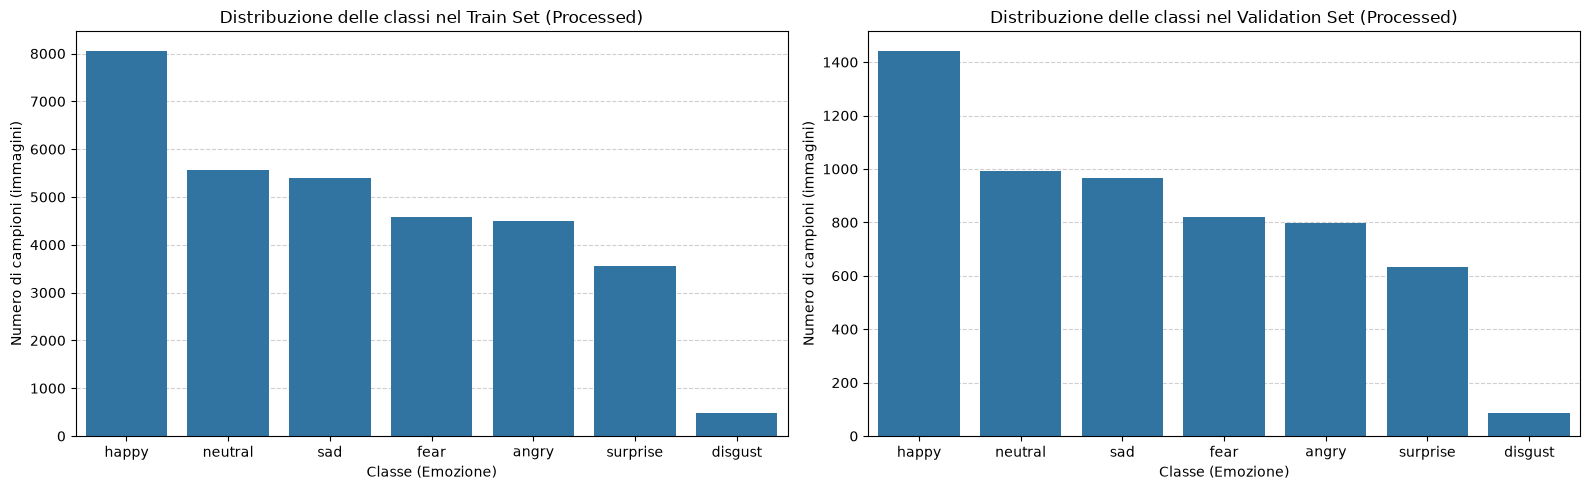


--- Train (Processed) ---
Immagini totali: 32155
- happy: 8062 campioni (25.07%)
- neutral: 5560 campioni (17.29%)
- sad: 5407 campioni (16.82%)
- fear: 4588 campioni (14.27%)
- angry: 4507 campioni (14.02%)
- surprise: 3554 campioni (11.05%)
- disgust: 477 campioni (1.48%)

--- Validation (Processed) ---
Immagini totali: 5741
- happy: 1443 campioni (25.13%)
- neutral: 993 campioni (17.30%)
- sad: 966 campioni (16.83%)
- fear: 819 campioni (14.27%)
- angry: 799 campioni (13.92%)
- surprise: 634 campioni (11.04%)
- disgust: 87 campioni (1.52%)


In [14]:
display_side_distr_classes("Processed", "Train", "Processed", "Validation")

### Confronto percentuale tra Train e Test Set

In [15]:
def show_distr_classes_percent(base, ax=None):
    base_dir = os.path.join(DATA_DIR, base)

    if base == "Original":
        name_dir = "Test"
    elif base == "Processed":
        name_dir = "Validation"
    else:
        raise ValueError("'base' deve essere 'Original' o 'Processed'")

    child_dir = os.path.join(base_dir, name_dir)
    train_dir = os.path.join(base_dir, "train")

    class_names = sorted(os.listdir(train_dir))
    data = []

    train_counts, tot_train = {}, 0

    for c in class_names:
        count = len(os.listdir(os.path.join(train_dir, c)))
        train_counts[c] = count
        tot_train += count

    test_counts, tot_test = {}, 0

    for c in class_names:
        count = len(os.listdir(os.path.join(child_dir, c)))
        test_counts[c] = count
        tot_test += count

    for c in class_names:
        data.append({
            "Emotion": c,
            "Percentage": train_counts[c] / tot_train * 100,
            "Split Dataset": "Train"
        })

        data.append({
            "Emotion": c,
            "Percentage": test_counts[c] / tot_test * 100,
            "Split Dataset": name_dir
        })

    df = pd.DataFrame(data)
    order = sorted(train_counts, key=train_counts.get, reverse=True)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
        created_fig = True

    sns.barplot(
        data=df,
        x="Emotion",
        y="Percentage",
        hue="Split Dataset",
        order=order,
        ax=ax
    )

    ax.set_title(f'Confronto della Distribuzione delle Classi: Train vs {name_dir} (%) - {base}', fontsize=14, pad=15)
    ax.set_ylabel('Percentuale sul totale dello split (%)')
    ax.set_xlabel('Classe (Emozione)')
    ax.grid(axis="y", linestyle="--", alpha=0.7)

    if created_fig:
        plt.tight_layout()
        plt.show()
        plt.close()

def display_side_distr_classes_percent(base1, base2):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    show_distr_classes_percent(base1, ax=axes[0])
    show_distr_classes_percent(base2, ax=axes[1])

    plt.tight_layout()
    plt.show()
    plt.close(fig)

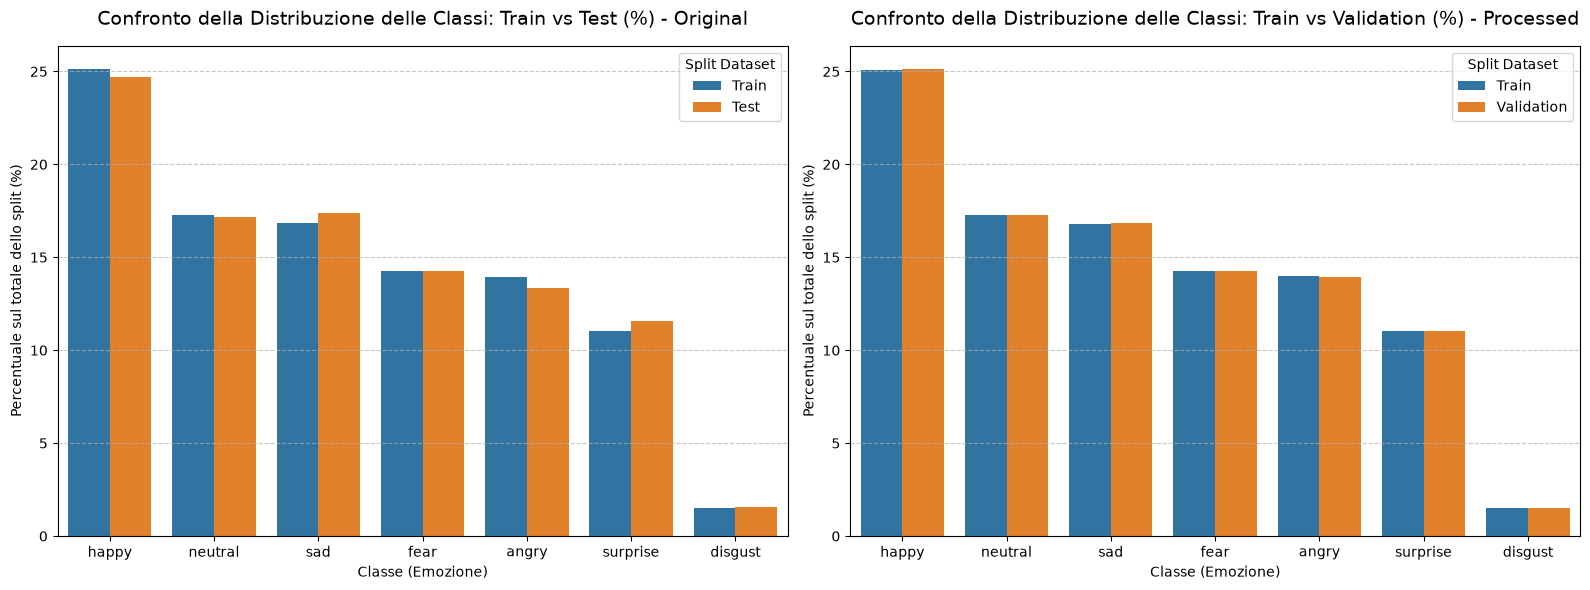

In [16]:
display_side_distr_classes_percent("Original", "Processed")